# VAE - ArtBench

https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/

## Setup

In [27]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [28]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [29]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Dataset

In [30]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = C:\Users\Jose\Mestrado\IAG_TP1
SCRIPTS_DIR    = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10
TRAINING CSV   = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [31]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [32]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

Dataset source: kaggle root='C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [33]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), # Inverte a pintura lateralmente
    transforms.RandomRotation(degrees=10),  # Roda até 10 graus
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [34]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [35]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [36]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


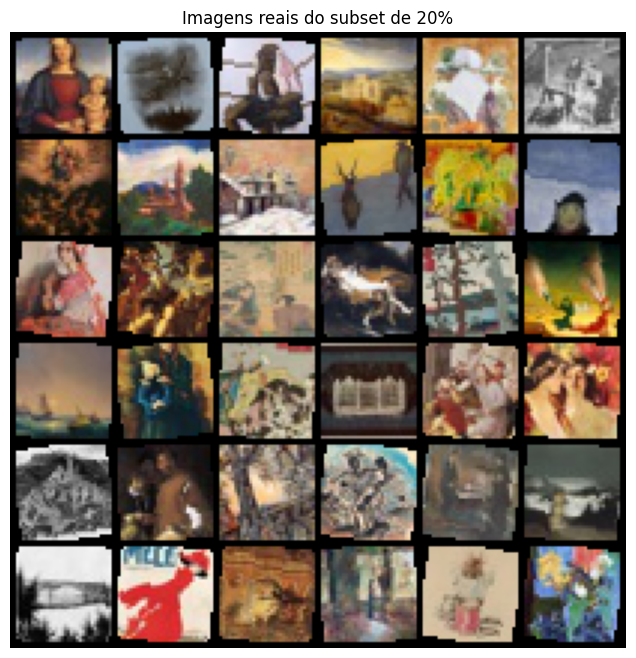

Exemplos de labels:
0: classe=renaissance 
1: classe=romanticism 
2: classe=expressionism 
3: classe=romanticism 
4: classe=post_impressionism 
5: classe=realism 
6: classe=renaissance 
7: classe=post_impressionism 
8: classe=post_impressionism 
9: classe=surrealism 
10: classe=post_impressionism 
11: classe=expressionism 


In [37]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## Difusion Model

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Parâmetros conforme o artigo
T = 300  # Timesteps (podes usar 1000 se tiveres GPU forte)
beta_start = 0.0001
beta_end = 0.02

# 1. Linear Schedule para os Betas
betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)

# 2. Derivação dos Alphas (conforme as fórmulas do link)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# 3. Cálculos para o processo Forward (q(x_t | x_0))
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# 4. Cálculos para o processo Backward (posterior variance)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def get_index_from_list(vals, t, x_shape):
    """Extrai o valor de 'vals' no índice 't' e ajusta o shape para as imagens."""
    batch_size = t.shape[0]
    out = vals.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [39]:
def forward_diffusion_sample(x_0, t, device="cpu"):
    """Recebe imagem limpa x_0 e retorna a versão ruidosa x_t."""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    # Média + Variância
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Definição do Embedding de Tempo (Crucial para Difusão)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 2. Bloco Básico da UNet
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # Primeira convolução
        h = self.relu(self.bnorm1(self.conv1(x)))
        # Injetar a informação do tempo t
        time_emb = self.relu(self.time_mlp(t))[(..., ) + (None, ) * 2]
        h = h + time_emb
        # Segunda convolução
        h = self.relu(self.bnorm2(self.conv2(h)))
        return h

# 3. A UNet propriamente dita
class SimpleDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.initial_conv(x)
        
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        for up in self.ups:
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            res = residuals.pop()
            x = torch.cat((x, res), dim=1) 
            x = up(x, t)
            
        return self.final_conv(x)

In [41]:
class SimpleDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        # MLP para processar o passo de tempo t
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        # Conv inicial para entrar na rede
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        # Encoder: Baixa a resolução (Downsampling)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        # Decoder: Sobe a resolução (Upsampling)
        # IMPORTANTE: O in_ch do bloco up é o dobro porque recebe o skip connection (concat)
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        # Camada final para voltar a ter 3 canais RGB
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        # 1. Embedding do tempo
        t = self.time_mlp(t)
        
        # 2. Passagem inicial
        x = self.initial_conv(x)
        
        # 3. Guardar os residuals para as skip connections
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        # 4. Upsampling com Skip Connections
        for up in self.ups:
            # Sobe a resolução (ex: 16x16 -> 32x32)
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            
            # Recupera a informação do encoder correspondente
            res = residuals.pop()
            
            # Concatena nos canais (dim=1)
            x = torch.cat((x, res), dim=1) 
            
            # Passa pelo bloco que agora aceita os canais duplicados
            x = up(x, t)
            
        return self.final_conv(x)

In [42]:
model_test = SimpleDiffusionUNet().to(DEVICE)
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
test_t = torch.randint(0, 300, (1,)).to(DEVICE)
output = model_test(test_input, test_t)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}") # Deve ser igual ao input!

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3, 32, 32])


In [43]:
def get_loss(model, x_0, t, device):
    # 1. Gerar ruído e versão ruidosa (Forward)
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    
    # 2. Prever o ruído com a UNet (Backward)
    noise_pred = model(x_noisy, t)
    
    # 3. Calcular o erro (MSE)
    return F.mse_loss(noise, noise_pred)

In [44]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [45]:
%pip install torchmetrics[image]
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [46]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

In [47]:
from pathlib import Path

# 1. Configurações (Ajusta conforme o teu notebook)
# Certifica-te que PROJECT_ROOT, DEVICE, LATENT_DIM e a classe VAE estão definidos
results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
seeds = [3, 17, 29, 58, 71, 89, 123, 256, 456] #falta o 512

In [48]:
EPOCHS = 200
def train_and_evaluate_diffusion_seed(seed):
    # 1. Configurar sementes para reprodutibilidade total
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 2. Inicializar Modelo, Otimizador e Métricas
    model = SimpleDiffusionUNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)

    # 3. Loop de Treino
    model.train()
    for epoch in range(EPOCHS):
        total_epoch_loss = 0
        for batch_idx, (x, _, _) in enumerate(train_loader):
            optimizer.zero_grad()
            x = x.to(DEVICE)
            
            # Escolher passos de tempo aleatórios
            t = torch.randint(0, T, (x.size(0),), device=DEVICE).long()
            
            # get_loss deve estar definida conforme as instruções anteriores
            loss = get_loss(model, x, t, DEVICE)
            
            loss.backward()
            optimizer.step()
            total_epoch_loss += loss.item()
        
        avg_loss = total_epoch_loss / len(train_loader)
        if (epoch + 1) % 5 == 0:
            print(f"Seed {seed} | Época {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

    # 4. Avaliação Final (Processo de Amostragem DDPM)
    model.eval()
    print(f"🎨 A gerar amostras para avaliação da Seed {seed} (isto pode demorar)...")
    
    # Precisamos de imagens reais para o FID/KID
    # E gerar imagens fakes do zero usando o processo reverso
    with torch.no_grad():
        # A. Atualizar métricas com imagens REAIS
        for x, _, _ in train_loader:
            real = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).to(DEVICE)
            fid_metric.update(real, real=True)
            kid_metric.update(real, real=True)
            if fid_metric.real_features_num_samples >= 1000:
                break

        # B. Gerar imagens FAKES (Processo de Sampling Completo)
        # Geramos em batches para não estourar a memória
        num_generated = 0
        batch_size_gen = 50 # Podes ajustar conforme a tua GPU
        
        while num_generated < 1000:
            # Começar com ruído puro
            img = torch.randn((batch_size_gen, 3, 32, 32), device=DEVICE)
            
            # Loop reverso de T até 0
            for i in reversed(range(0, T)):
                t_idx = torch.full((batch_size_gen,), i, device=DEVICE, dtype=torch.long)
                predicted_noise = model(img, t_idx)
                
                # Coeficientes do Scheduler (alphas, betas, etc. definidos globalmente)
                alpha = get_index_from_list(alphas, t_idx, img.shape)
                alpha_cumprod_t = get_index_from_list(alphas_cumprod, t_idx, img.shape)
                beta_t = get_index_from_list(betas, t_idx, img.shape)
                
                if i > 0:
                    noise = torch.randn_like(img)
                else:
                    noise = 0
                
                # Fórmula de x_{t-1}
                img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) + torch.sqrt(beta_t) * noise
            
            # Converter para uint8 [0, 255]
            fake = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(fake, real=False)
            kid_metric.update(fake, real=False)
            
            num_generated += batch_size_gen

    # 5. Compilar resultados
    fid_score = fid_metric.compute().item()
    kid_mean, kid_std = kid_metric.compute()
    
    model_save_path = results_dir / f"diffusion_model_seed_200_epochs{seed}.pth"
    torch.save(model.state_dict(), model_save_path)

    return {
        "seed": seed,
        "metrics": {
            "fid": fid_score,
            "kid": kid_mean.item(),
            "kid_std": kid_std.item()
        }
    }

In [49]:
%pip install torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.


In [50]:
import json
import time
from pathlib import Path
import numpy as np

# 1. Configurações de Caminhos e Seeds
# Usa a tua string direta como preferiste antes
results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
results_dir.mkdir(parents=True, exist_ok=True)

seeds_diffusion = [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]
all_diffusion_results = []

print(f"🚀 Iniciando Protocolo de Difusão para {len(seeds_diffusion)} seeds...")
start_global = time.time()

for s in seeds_diffusion:
    print(f"\n--- 🛰️ A processar Seed Difusão: {s} ---")
    start_seed = time.time()
    
    # Chama a função que criámos no passo anterior
    # Certifica-te que a função 'train_and_evaluate_diffusion_seed' está definida
    try:
        res = train_and_evaluate_diffusion_seed(s)
        all_diffusion_results.append(res)
        
        # Guardar JSON individual imediatamente (prevenção de crashes)
        seed_path = results_dir / f"metrics_diffusion_seed{s}.json"
        with open(seed_path, "w", encoding="utf-8") as f:
            json.dump(res, f, indent=2)
            
        duracao = (time.time() - start_seed) / 60
        print(f"✅ Seed {s} concluída em {duracao:.2f} min | FID: {res['metrics']['fid']:.2f}")
        
    except Exception as e:
        print(f"❌ Erro na Seed {s}: {e}")

# 2. Cálculo das Estatísticas Finais (Mean ± Std)
if all_diffusion_results:
    fids = [r["metrics"]["fid"] for r in all_diffusion_results]
    kids = [r["metrics"]["kid"] for r in all_diffusion_results]
    
    summary_diff = {
        "statistics": {
            "fid_mean": float(np.mean(fids)),
            "fid_std": float(np.std(fids)),
            "kid_mean": float(np.mean(kids)),
            "kid_std": float(np.std(kids))
        },
        "all_seeds": all_diffusion_results,
        "total_duration_minutes": (time.time() - start_global) / 60
    }

    # 3. Guardar o Resumo Final
    summary_path = results_dir / "diffusion_statistical_summary_200_epochs.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary_diff, f, indent=2)

    print("\n" + "="*50)
    print("📊 RESUMO FINAL DIFUSÃO")
    print("="*50)
    print(f"FID: {summary_diff['statistics']['fid_mean']:.2f} ± {summary_diff['statistics']['fid_std']:.2f}")
    print(f"KID: {summary_diff['statistics']['kid_mean']:.4f} ± {summary_diff['statistics']['kid_std']:.4f}")
    print(f"Resultados guardados em: {results_dir}")
    print("="*50)

🚀 Iniciando Protocolo de Difusão para 10 seeds...

--- 🛰️ A processar Seed Difusão: 3 ---
Seed 3 | Época 5/200 | Loss: 0.105654
Seed 3 | Época 10/200 | Loss: 0.091168
Seed 3 | Época 15/200 | Loss: 0.085778
Seed 3 | Época 20/200 | Loss: 0.083506
Seed 3 | Época 25/200 | Loss: 0.080592
Seed 3 | Época 30/200 | Loss: 0.081916
Seed 3 | Época 35/200 | Loss: 0.080253
Seed 3 | Época 40/200 | Loss: 0.078802
Seed 3 | Época 45/200 | Loss: 0.077323
Seed 3 | Época 50/200 | Loss: 0.074647
Seed 3 | Época 55/200 | Loss: 0.076065
Seed 3 | Época 60/200 | Loss: 0.075529
Seed 3 | Época 65/200 | Loss: 0.076484
Seed 3 | Época 70/200 | Loss: 0.074270
Seed 3 | Época 75/200 | Loss: 0.075736
Seed 3 | Época 80/200 | Loss: 0.071712
Seed 3 | Época 85/200 | Loss: 0.074824
Seed 3 | Época 90/200 | Loss: 0.074620
Seed 3 | Época 95/200 | Loss: 0.075290
Seed 3 | Época 100/200 | Loss: 0.072749
Seed 3 | Época 105/200 | Loss: 0.072852
Seed 3 | Época 110/200 | Loss: 0.073431
Seed 3 | Época 115/200 | Loss: 0.073057
Seed 3 | É

A carregar modelos de: C:\Users\Jose\Mestrado\IAG_TP1\results

Gerando amostras para a Seed 3...


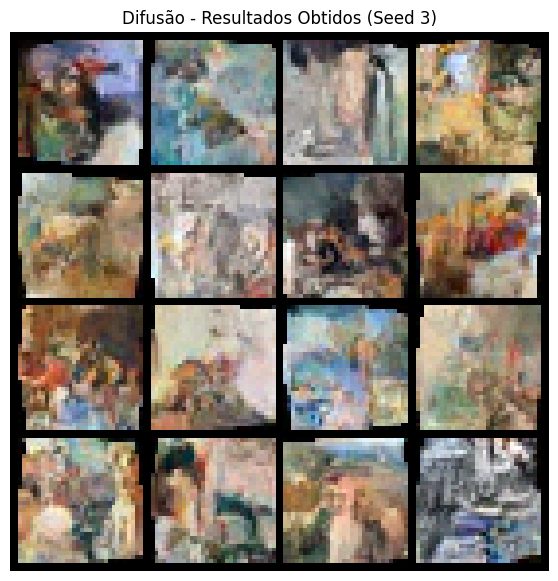


Gerando amostras para a Seed 17...


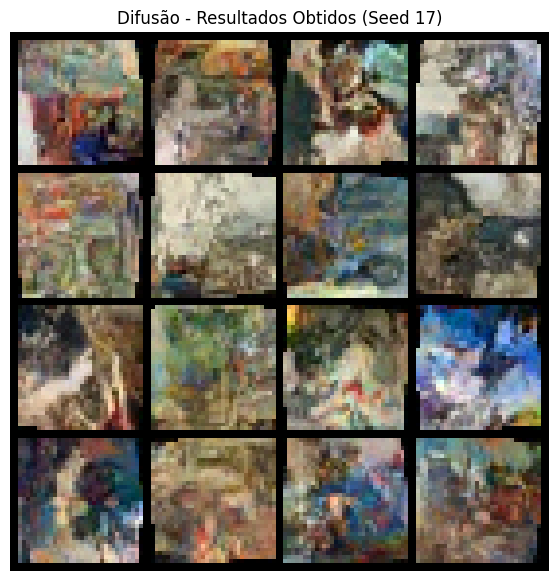


Gerando amostras para a Seed 29...


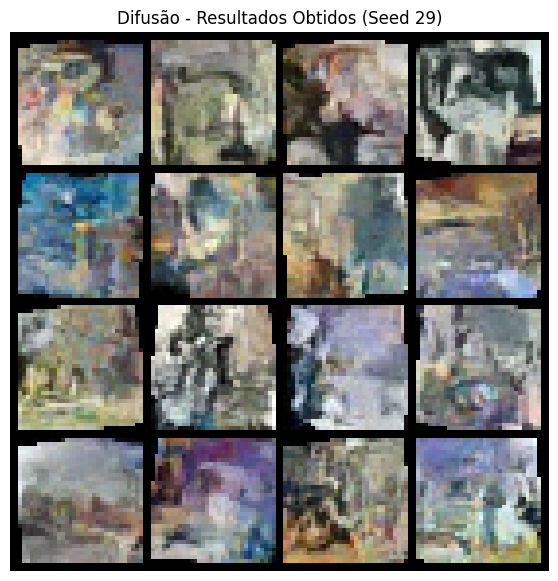


Gerando amostras para a Seed 58...


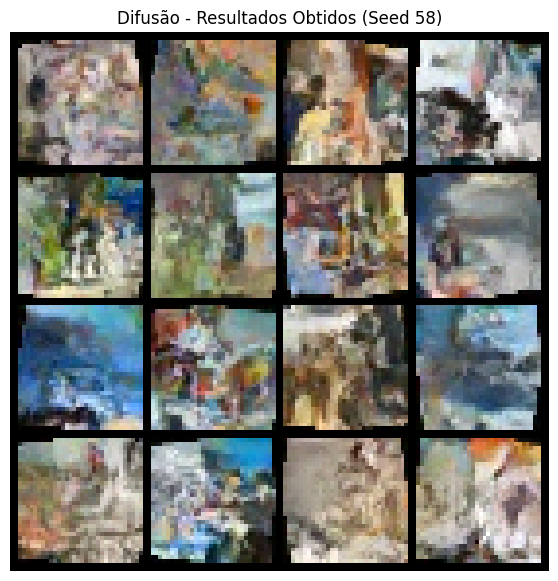


Gerando amostras para a Seed 71...


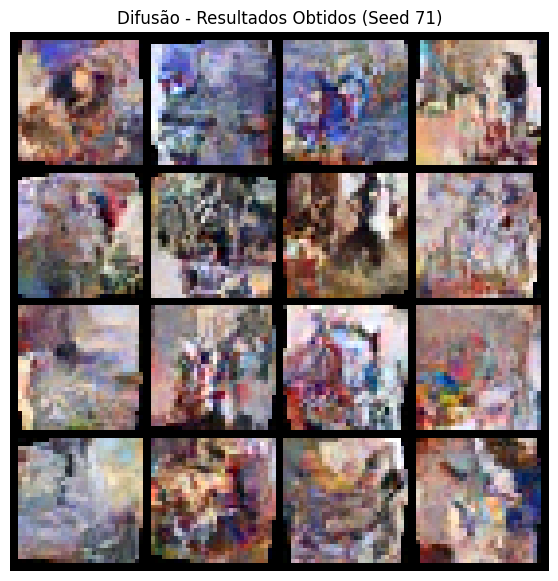


Gerando amostras para a Seed 89...


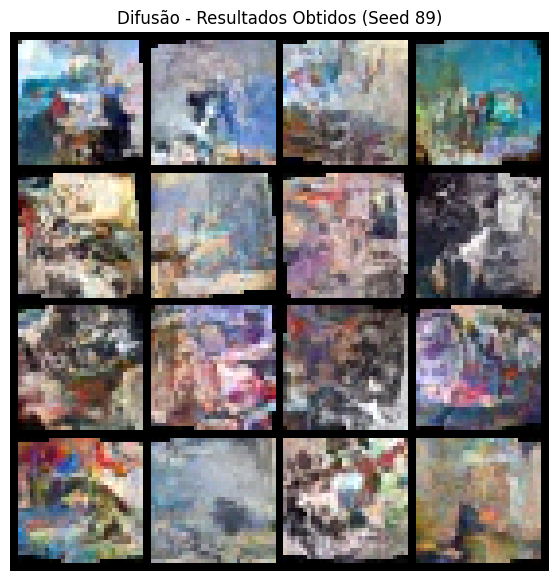


Gerando amostras para a Seed 123...


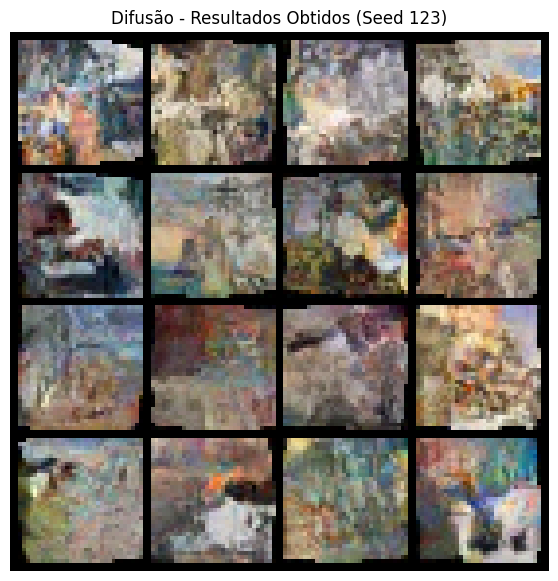


Gerando amostras para a Seed 256...


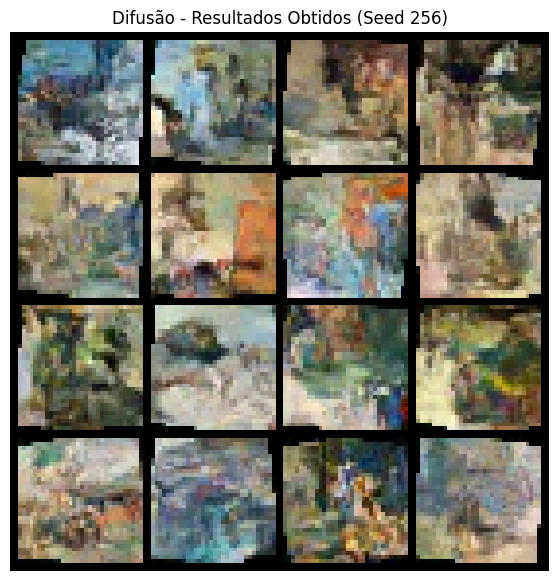


Gerando amostras para a Seed 456...


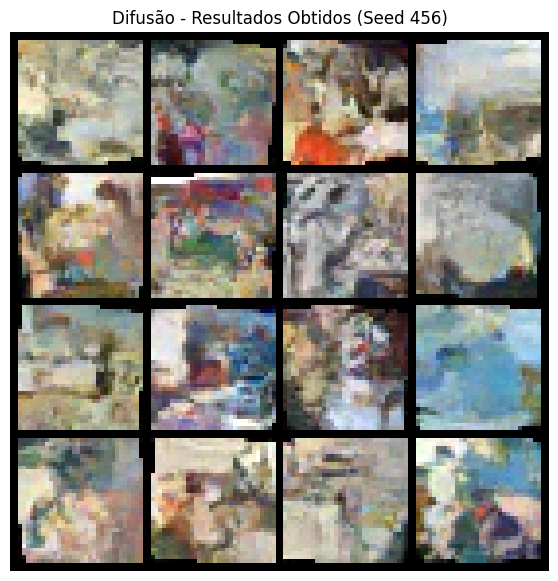


Gerando amostras para a Seed 512...


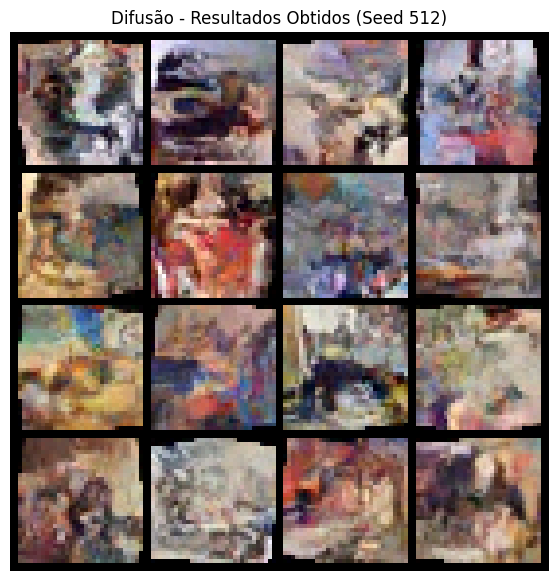

In [53]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from pathlib import Path

@torch.no_grad()
def load_and_visualize_diffusion(seeds_list, results_path, n_samples=16):
    # 1. Instanciar a arquitetura (tem de ser a mesma usada no treino)
    model = SimpleDiffusionUNet().to(DEVICE)
    results_path = Path(results_path)
    
    print(f"A carregar modelos de: {results_path}")

    for seed in seeds_list:
        # Procurar o ficheiro .pth da seed específica
        model_file = results_path / f"diffusion_model_seed_100_epochs{seed}.pth"
        
        if not model_file.exists():
            print(f"Ficheiro não encontrado: {model_file.name}")
            continue
            
        print(f"\nGerando amostras para a Seed {seed}...")
        
        # CARREGAR OS PESOS
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()
        
        # PROCESSO DE DENOISING (Processo Reverso)
        # Começamos com ruído aleatório
        img = torch.randn((n_samples, 3, 32, 32), device=DEVICE)
        
        for i in reversed(range(0, T)):
            t = torch.full((n_samples,), i, device=DEVICE, dtype=torch.long)
            
            # Prever o ruído com o modelo carregado
            predicted_noise = model(img, t)
            
            # Recuperar parâmetros do scheduler (devem estar no teu ambiente global)
            alpha = get_index_from_list(alphas, t, img.shape)
            alpha_cumprod_t = get_index_from_list(alphas_cumprod, t, img.shape)
            beta_t = get_index_from_list(betas, t, img.shape)
            
            if i > 0:
                noise = torch.randn_like(img)
            else:
                noise = 0
                
            # Fórmula de x_{t-1}
            img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) \
                  + torch.sqrt(beta_t) * noise
        
        # Formatação final para visualização
        img = (img.clamp(-1, 1) + 1) / 2
        grid = make_grid(img, nrow=4, padding=2).permute(1, 2, 0).cpu().numpy()
        
        plt.figure(figsize=(7, 7))
        plt.imshow(grid)
        plt.axis('off')
        plt.title(f"Difusão - Resultados Obtidos (Seed {seed})")
        plt.show()

# --- EXECUÇÃO ---
# Usa o caminho da tua pasta onde estão os .pth
resultados = r"C:\Users\Jose\Mestrado\IAG_TP1\results"
seeds = [3, 17, 29, 58, 71, 89, 123, 256, 456, 512]

load_and_visualize_diffusion(seeds, resultados, n_samples=16)